# Ứng Dụng Machine Learning trong Dự Đoán Khả Năng Rời Bỏ Dịch Vụ của Khách Hàng tại Ngân Hàng Việt Nam
### CS114 - Máy học | Nhóm 3

**Dataset:** Vietnam Bank Churn Dataset - 2025 (Kaggle)

**Models:** Logistic Regression, Decision Tree, Random Forest,  XGBoost

**Bài toán:** Classification (Binary Classification)

**Sample size:** 80,000 dòng (Imbalanced)

---

## Import thư viện và load data

In [1]:
# Basic
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb

# Imbalanced
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# SHAP
try:
    import shap
    SHAP_OK = True
except ImportError:
    print('Cài shap: pip install shap')
    SHAP_OK = False


In [2]:
# ── Load dữ liệu trên Google Colab ─────────────────────────────────────
# Cách 1: Upload file CSV thủ công (kéo thả hoặc dùng files.upload)
from google.colab import files
import io

print('Chọn file bank_churn_dataset_80k.csv từ máy tính...')
uploaded = files.upload()

# Đọc file vừa upload
filename = list(uploaded.keys())[0]
print(f'\nĐã upload: {filename}')


Chọn file bank_churn_dataset_80k.csv từ máy tính...


Saving bank_churn_dataset_80k.csv to bank_churn_dataset_80k.csv

Đã upload: bank_churn_dataset_80k.csv


In [3]:
# ── Đọc dataset ─────────────────────────────────────────────────────────
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (80000, 26)
Columns: ['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'exit', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group']


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,...,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,...,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,...,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,...,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,...,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (80000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member      

,id,credit_sco,age,balance,monthly_ir,tenure_ye,married,nums_card,nums_service,last_transaction_month,engagement_score,risk_score,cluster_group
count,80000.000000,80000.000000,80000.000000,8.000000e+04,8.000000e+04,80000.000000,80000.000000,80000.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,80000.000000
mean,40000.500000,684.321137,49.381862,6.118320e+07,3.778820e+07,1.777250,0.970825,2.634688,3.564425,8.831755e+06,31.725400,0.269260,1.971037
std,23094.155105,51.169733,15.067480,8.868620e+07,3.655107e+07,1.315828,0.694698,1.218556,2.002448,3.378683e+07,23.474862,0.091891,1.040763
min,1.000000,495.000000,20.000000,4.086630e+05,3.000000e+06,0.000000,0.000000,1.000000,1.000000,0.000000e+00,7.000000,0.017300,1.000000
25%,20000.750000,649.000000,38.000000,1.462592e+07,1.400000e+07,1.000000,1.000000,2.000000,2.000000,0.000000e+00,16.000000,0.200400,1.000000
50%,40000.500000,682.000000,47.000000,3.090276e+07,2.300000e+07,2.000000,1.000000,2.000000,3.000000,0.000000e+00,22.000000,0.277400,2.000000
75%,60000.250000,718.000000,58.000000,6.960994e+07,4.700000e+07,3.000000,1.000000,3.000000,5.000000,0.000000e+00,38.000000,0.338900,2.000000
max,80000.000000,800.000000,90.000000,1.000000e+09,2.160000e+08,4.000000,3.000000,5.000000,8.000000,6.000000e+08,100.000000,0.540400,4.000000


In [5]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values:\n", missing)

Missing values:
 Series([], dtype: int64)


In [6]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


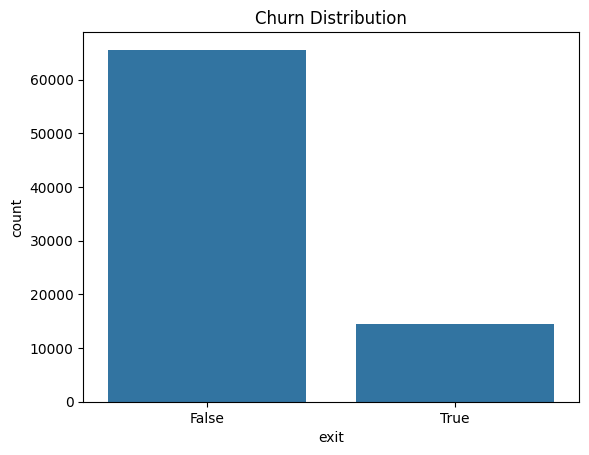

,proportion
exit,
False,82.0
True,18.0


In [7]:
# Target distribution
sns.countplot(x='exit', data=df)
plt.title("Churn Distribution")
plt.show()

df['exit'].value_counts(normalize=True) * 100

## EDA

### Phân tích đơn biến

In [8]:
# Numerical features — all numeric columns except target
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'exit']

print("Numerical columns:", num_cols)


Numerical columns: ['id', 'credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']


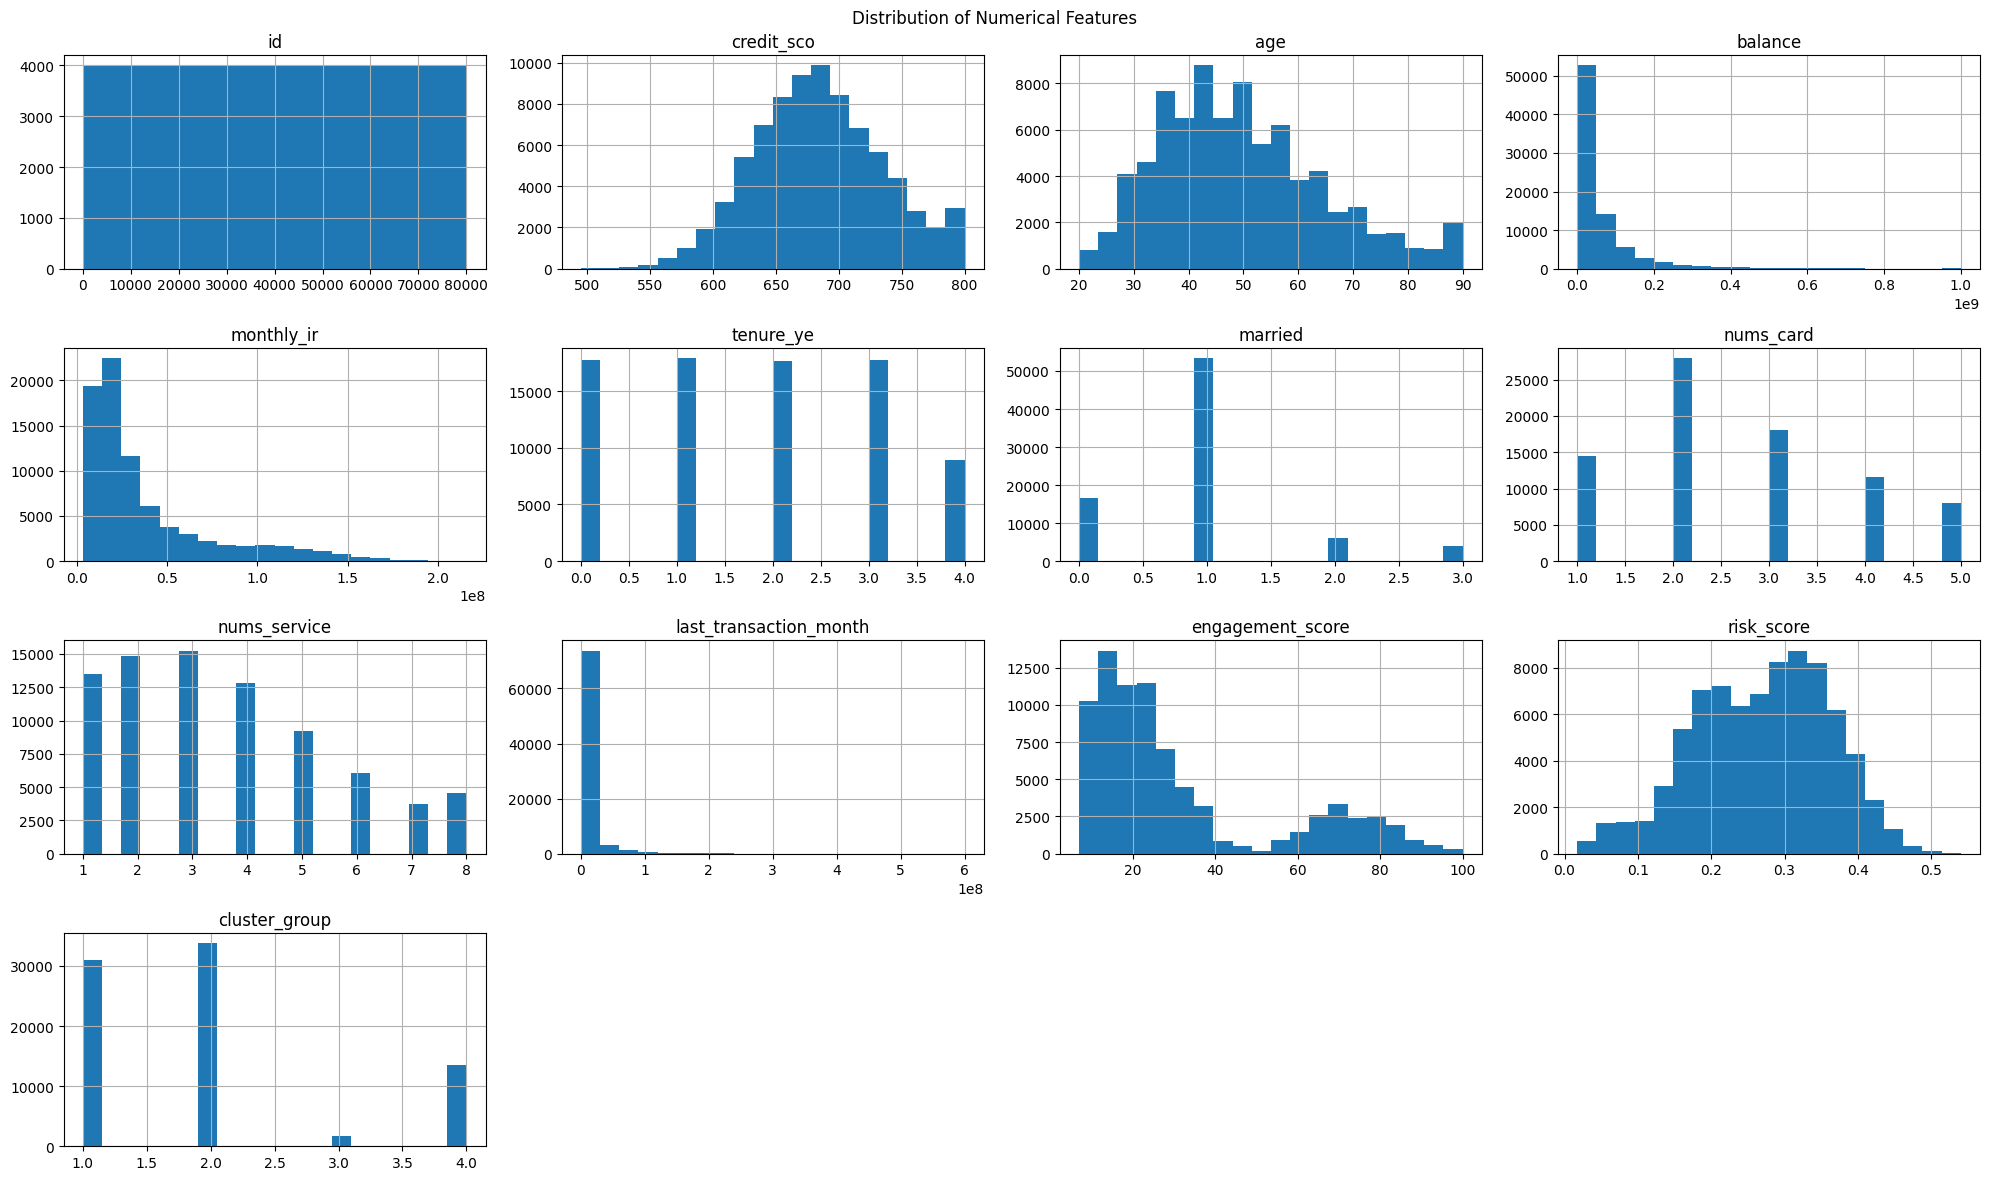

In [9]:
# num_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']

df[num_cols].hist(bins=20, figsize=(20, 12))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


In [10]:
# Categorical features — all object columns
cat_cols = [c for c in df.select_dtypes(include='object').columns]
print("Categorical columns:", cat_cols)

# cat_cols = ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']

Categorical columns: ['full_name', 'gender', 'occupation', 'address', 'origin_province', 'last_active_date', 'created_date', 'customer_segment', 'loyalty_level', 'digital_behavior', 'risk_segment']


In [11]:
for col in cat_cols:
    freq_df = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq_df["pct"] = (freq_df["count"] / len(df) * 100).round(4)

    print(f"\n===== Frequency Table: {col} =====")
    display(freq_df)


===== Frequency Table: full_name =====


,full_name,count,pct
0,Lê Minh Quang,42,0.0525
1,Vũ Đức Quang,41,0.0512
2,Phạm Anh Quang,41,0.0512
3,Mai Thanh Quang,40,0.0500
4,Mai Hữu Quang,38,0.0475
...,...,...,...
5095,Dương Thu Thành,5,0.0062
5096,Bùi Quang Nhiên,5,0.0062
5097,Đặng Văn Trung,4,0.0050
5098,Mai Thanh Bảo,4,0.0050



===== Frequency Table: gender =====


,gender,count,pct
0,male,40008,50.01
1,female,39992,49.99



===== Frequency Table: occupation =====


...

,loyalty_level,count,pct
0,Bronze,69252,86.5650
1,Silver,8977,11.2213
2,Gold,1771,2.2138



===== Frequency Table: digital_behavior =====


,digital_behavior,count,pct
0,offline,62824,78.53
1,mobile,17176,21.47



===== Frequency Table: risk_segment =====


,risk_segment,count,pct
0,Low,74753,93.4412
1,Medium,5247,6.5588


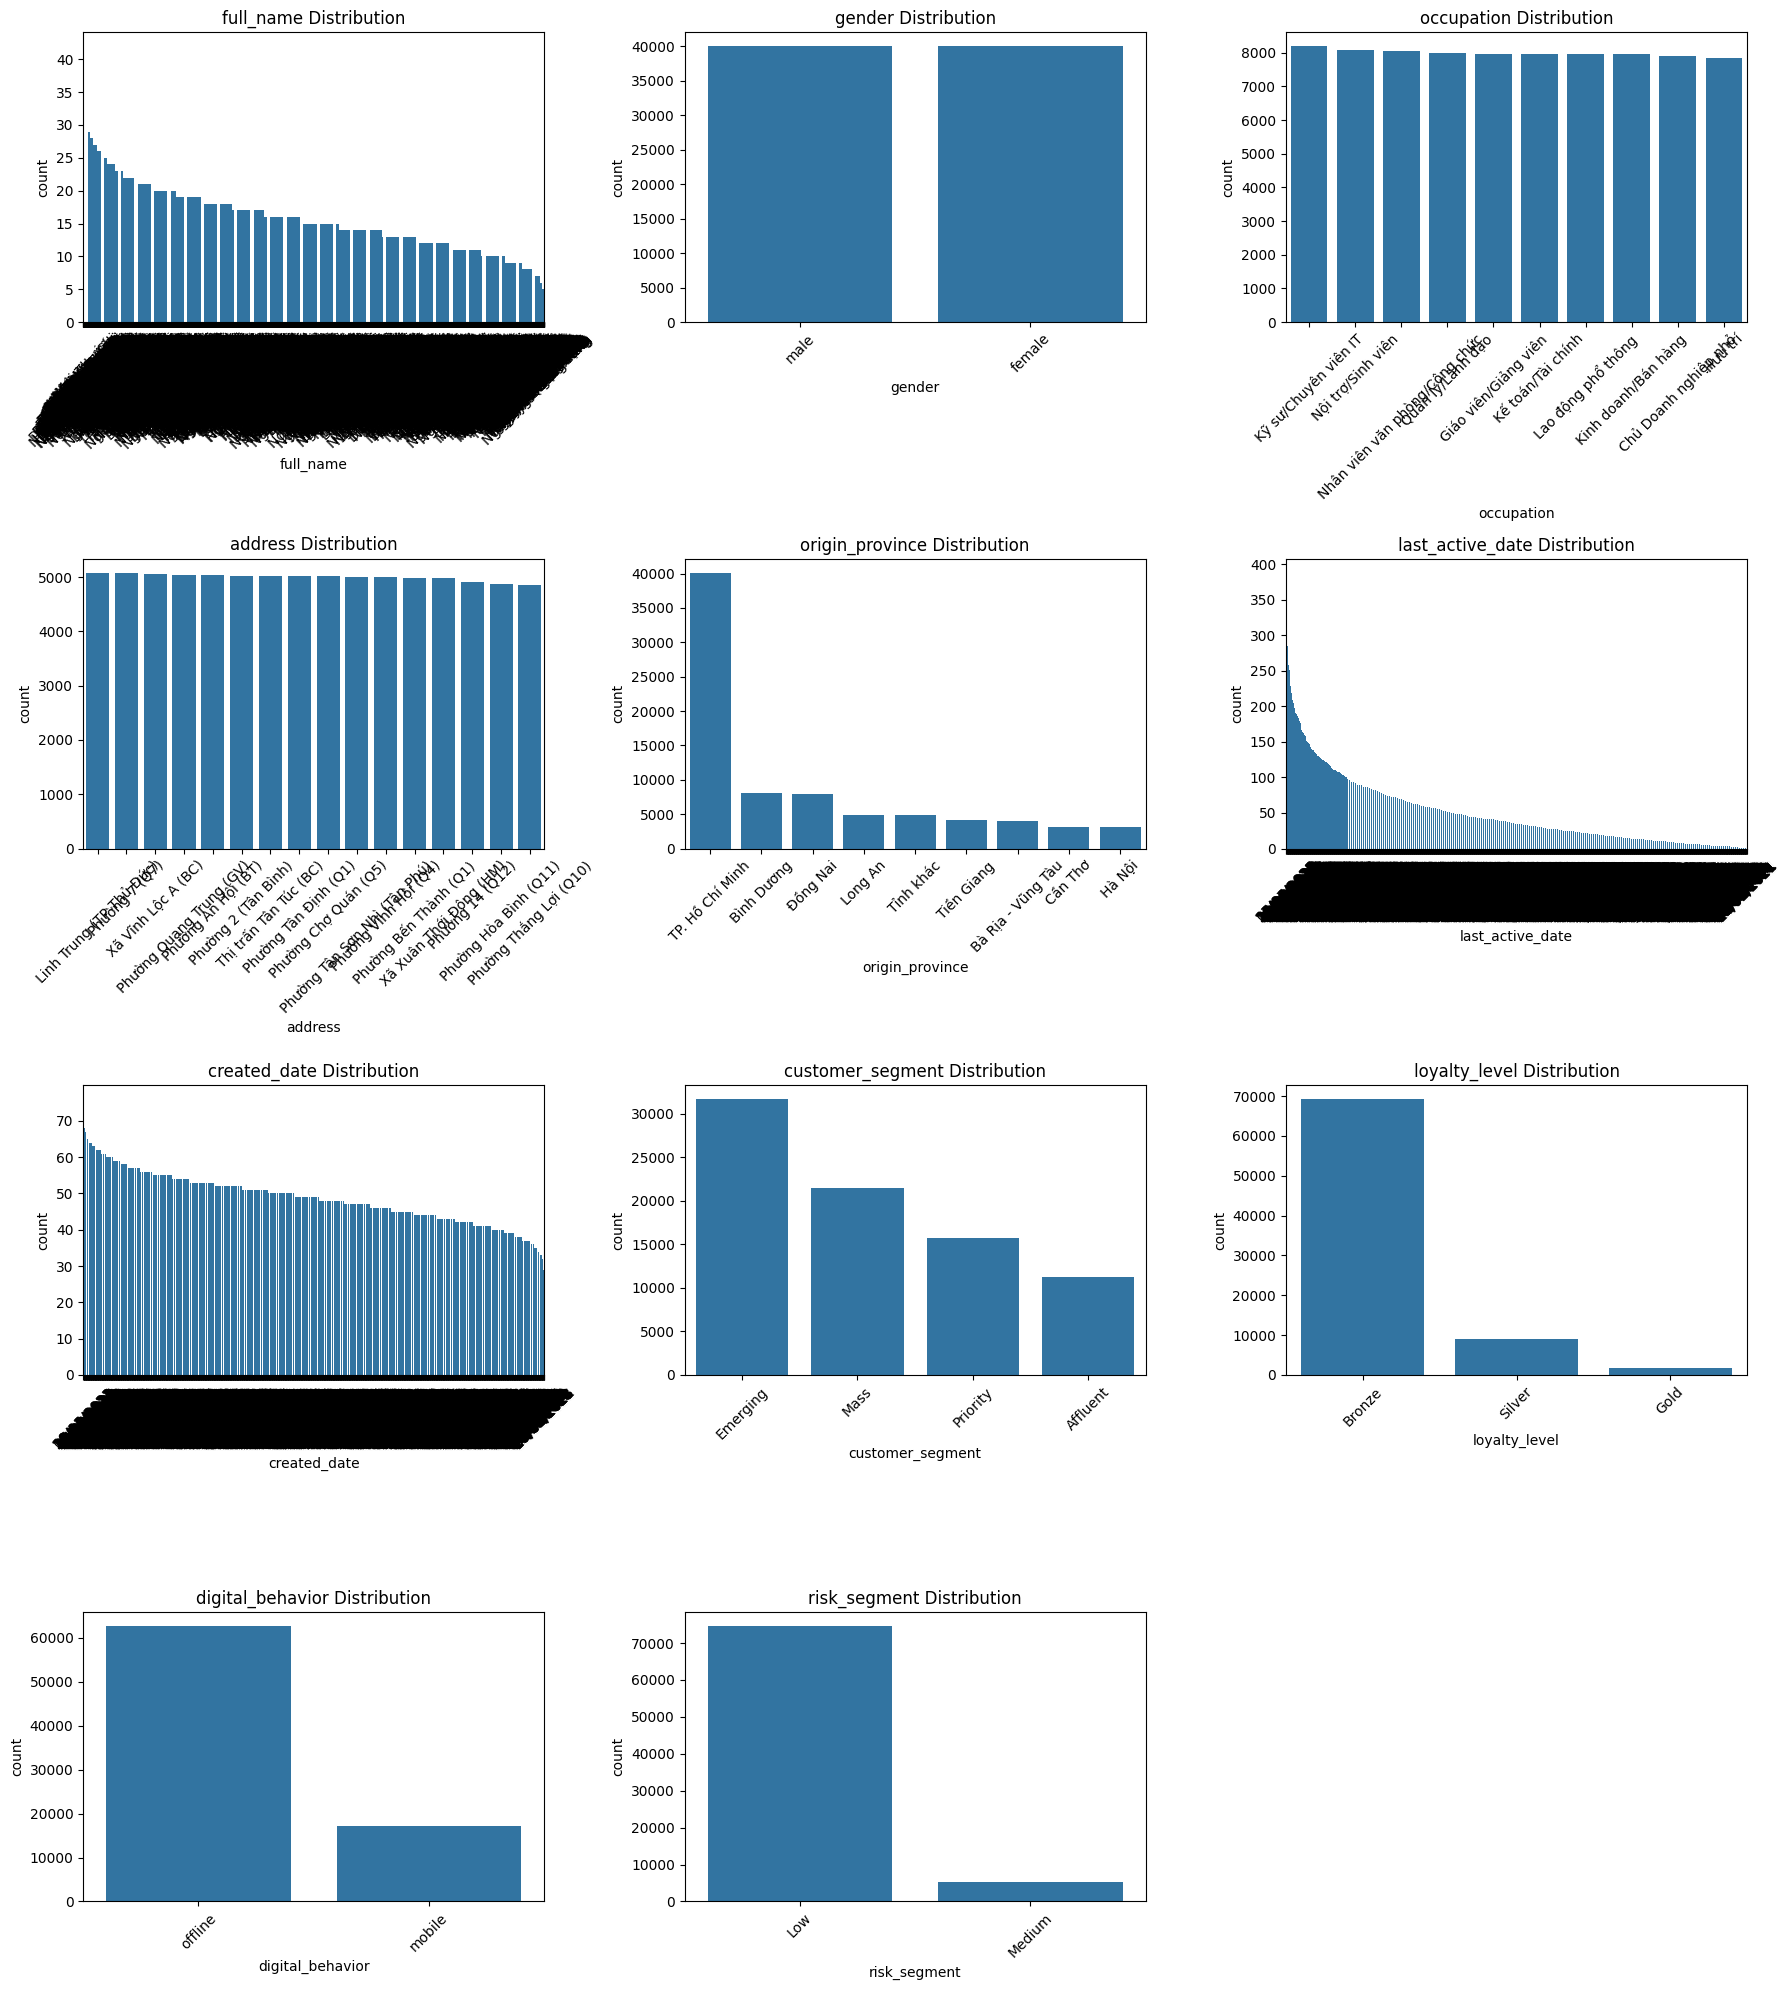

In [12]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích đa biến

In [13]:
cat_cols = ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']

num_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']


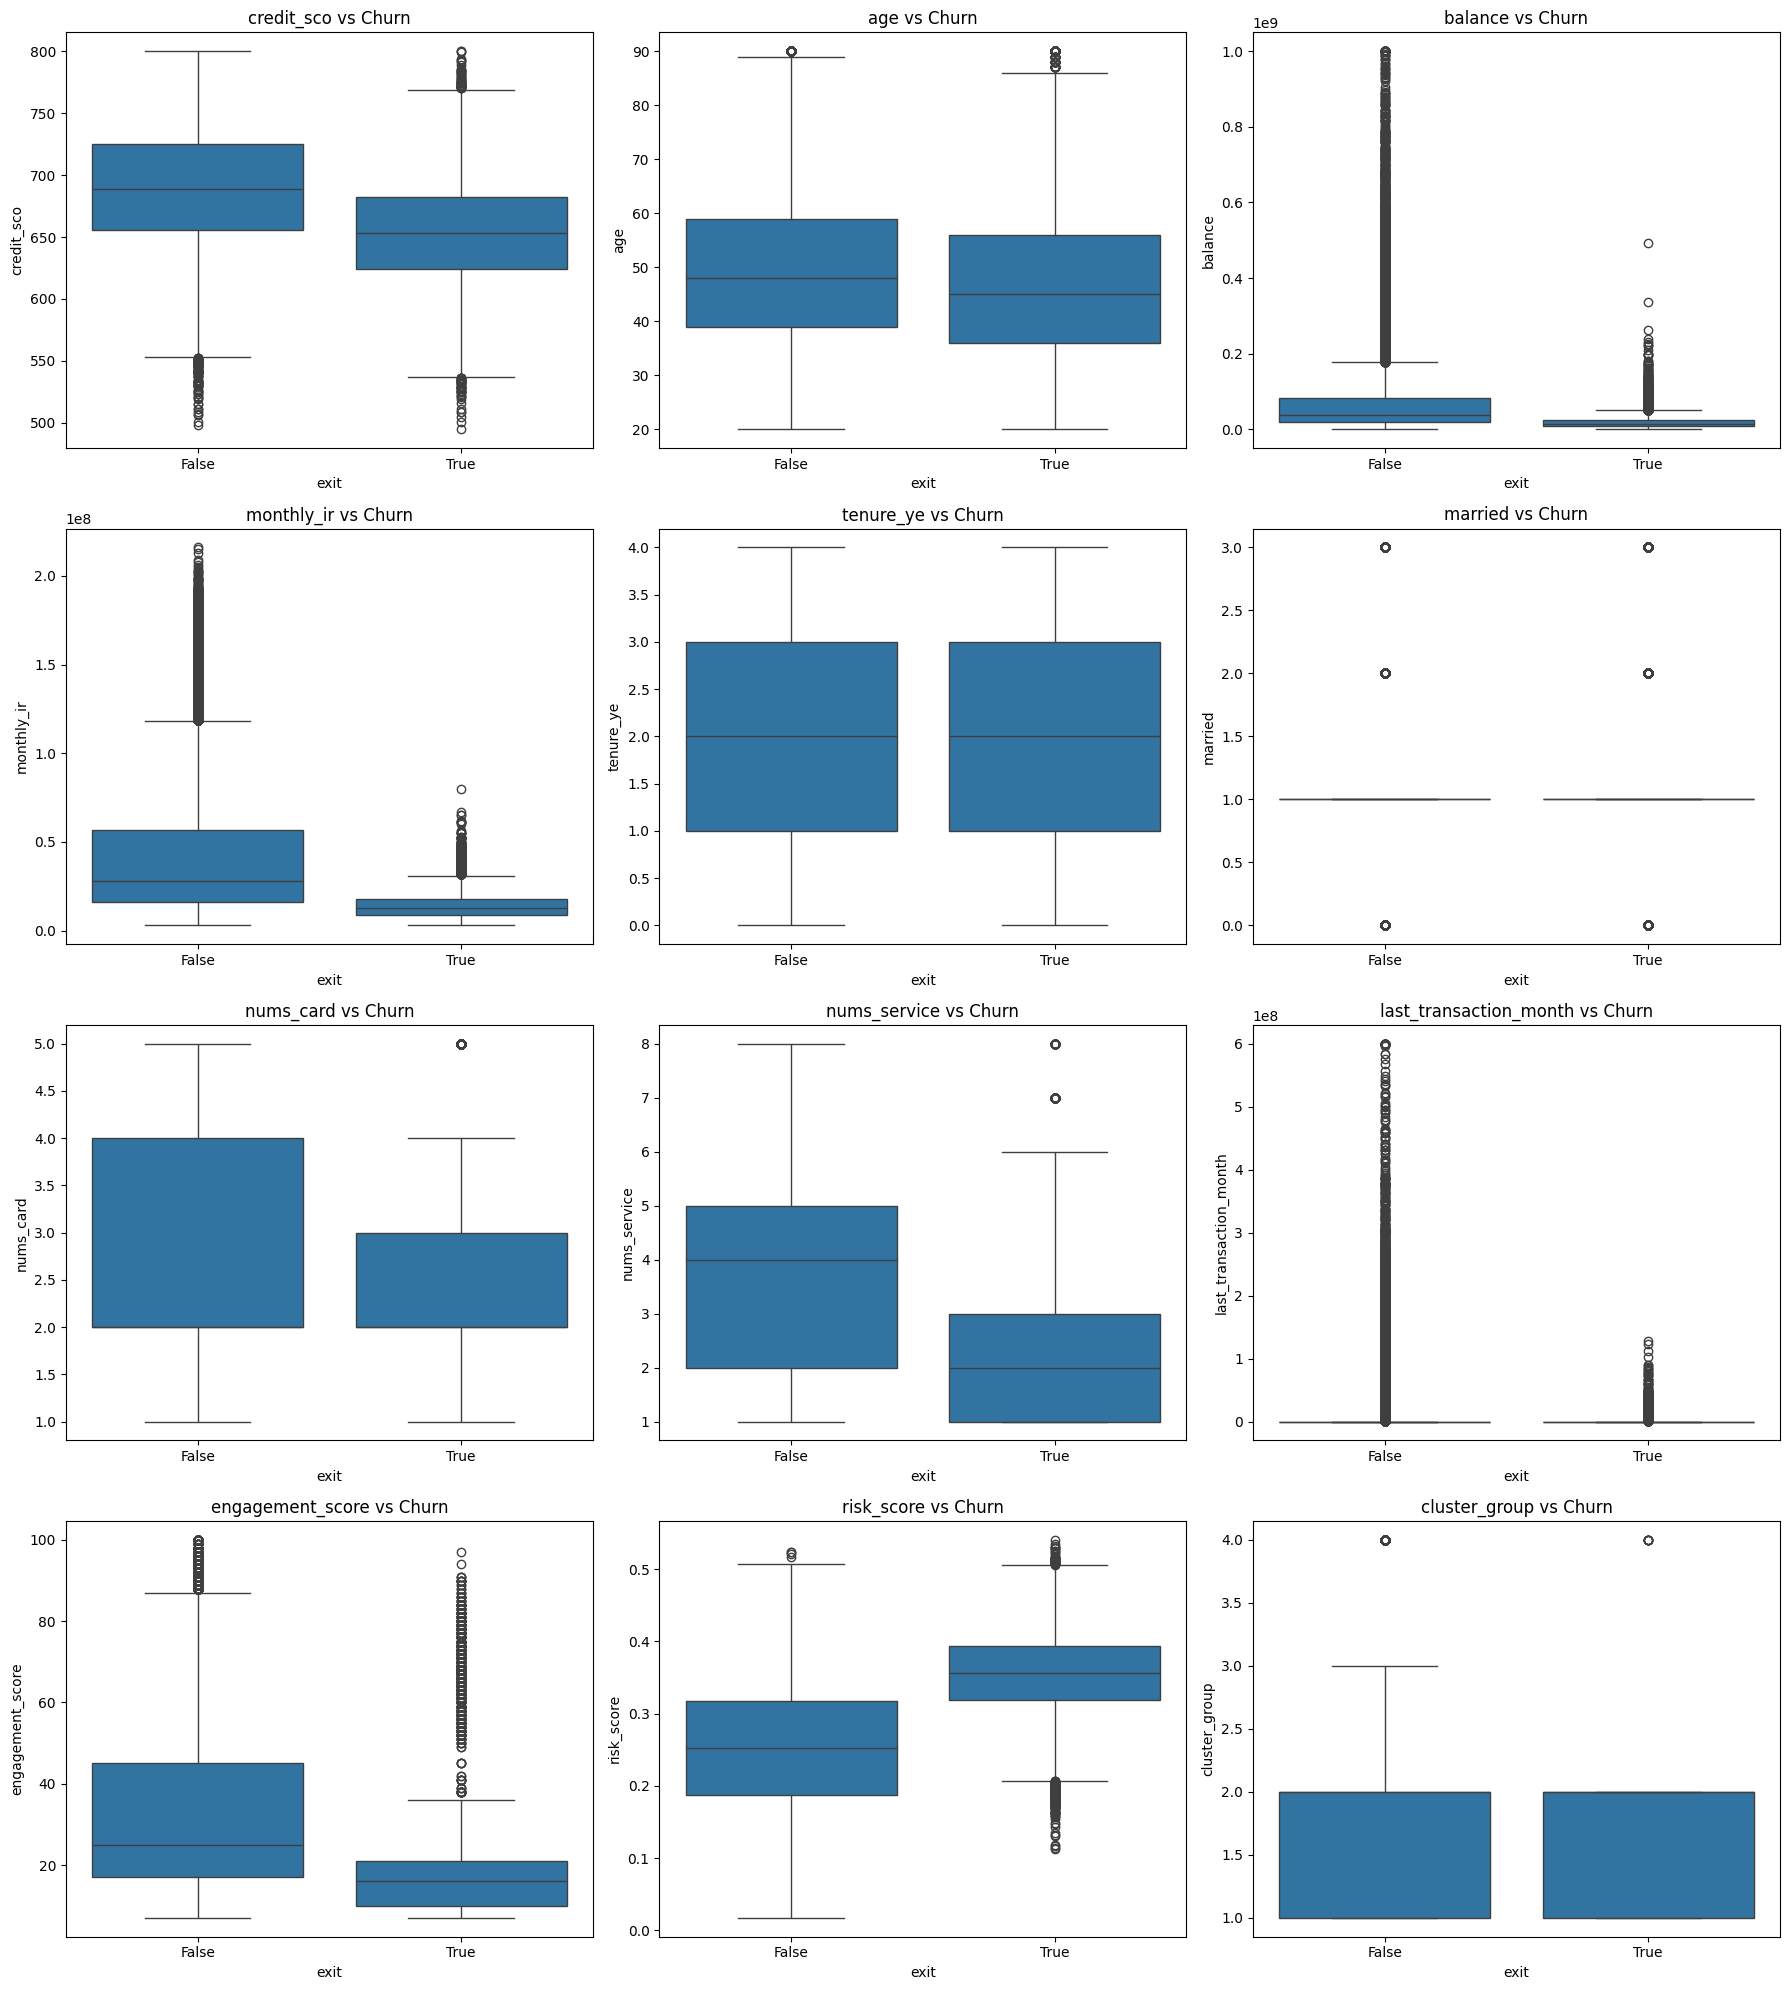

In [14]:
# Churn vs numerical
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='exit', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

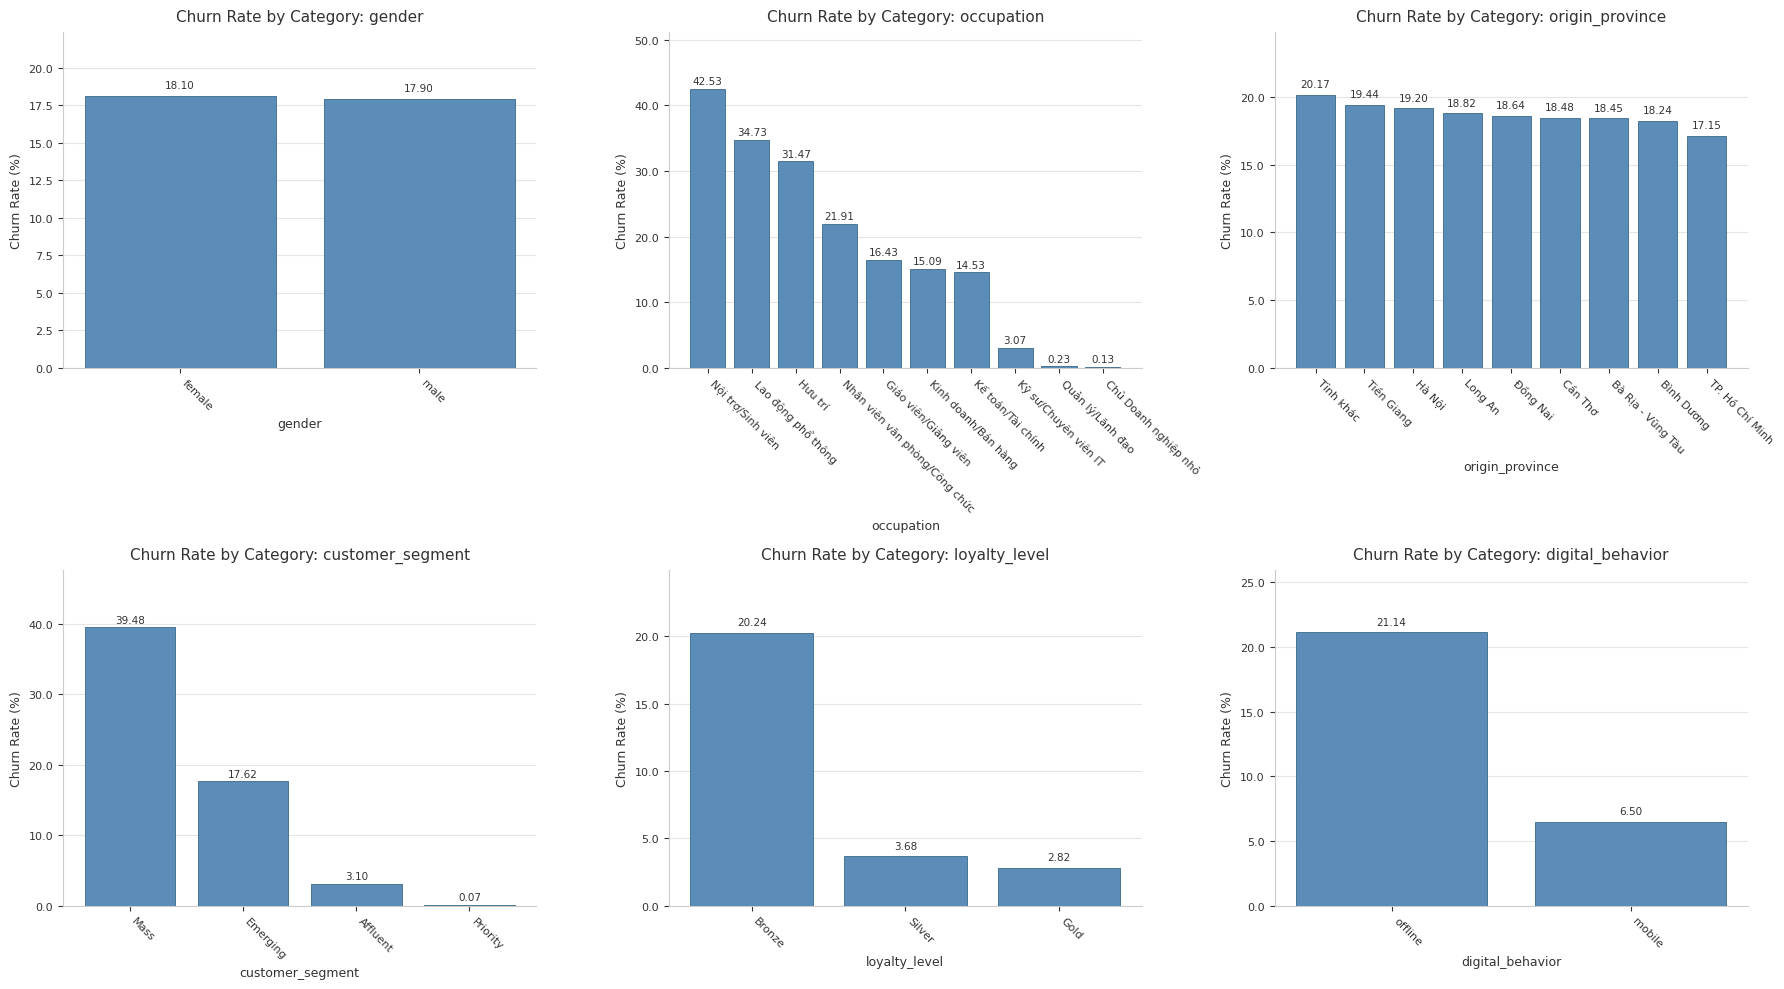

In [15]:
# Churn vs categorical
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math

# ── Shared style constants (match your boxplot palette) ──────────────────────
BOX_COLOR   = "#5B8DB8"   # seaborn default blue used in the boxplots
EDGE_COLOR  = "#3A6A8A"
TEXT_COLOR  = "#333333"
BG_COLOR    = "white"
GRID_COLOR  = "#E5E5E5"

def _apply_base_style(ax, title, xlabel, ylabel):
    """Apply the same base style used by the sns.boxplot panels."""
    ax.set_facecolor(BG_COLOR)
    ax.set_title(title, fontsize=11, color=TEXT_COLOR, pad=8)
    ax.set_xlabel(xlabel, fontsize=9,  color=TEXT_COLOR)
    ax.set_ylabel(ylabel, fontsize=9,  color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Categorical churn-rate bar charts ────────────────────────────────────────
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.patch.set_facecolor(BG_COLOR)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Build churn-rate DataFrame
    plot_df = (
        pd.crosstab(df[col], df["exit"], normalize="index", dropna=False)
        .reset_index()
    )
    plot_df["churn_rate_pct"] = (plot_df[1] * 100) if 1 in plot_df.columns else 0.0
    plot_df[col] = plot_df[col].astype(str)
    plot_df = plot_df.sort_values("churn_rate_pct", ascending=False)

    # Draw bars
    bars = ax.bar(
        plot_df[col],
        plot_df["churn_rate_pct"],
        color=BOX_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.6,
        zorder=3,
    )

    # Annotate bar tops (same pattern as your boxplot outlier dots)
    for bar, val in zip(bars, plot_df["churn_rate_pct"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{val:.2f}",
            ha="center", va="bottom",
            fontsize=7.5, color=TEXT_COLOR,
        )

    _apply_base_style(
        ax,
        title=f"Churn Rate by Category: {col}",
        xlabel=col,
        ylabel="Churn Rate (%)",
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=8)

    # Give headroom above tallest bar for the annotation
    ax.set_ylim(0, plot_df["churn_rate_pct"].max() * 1.18 + 1)

# Hide any spare panels (same pattern you already use)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

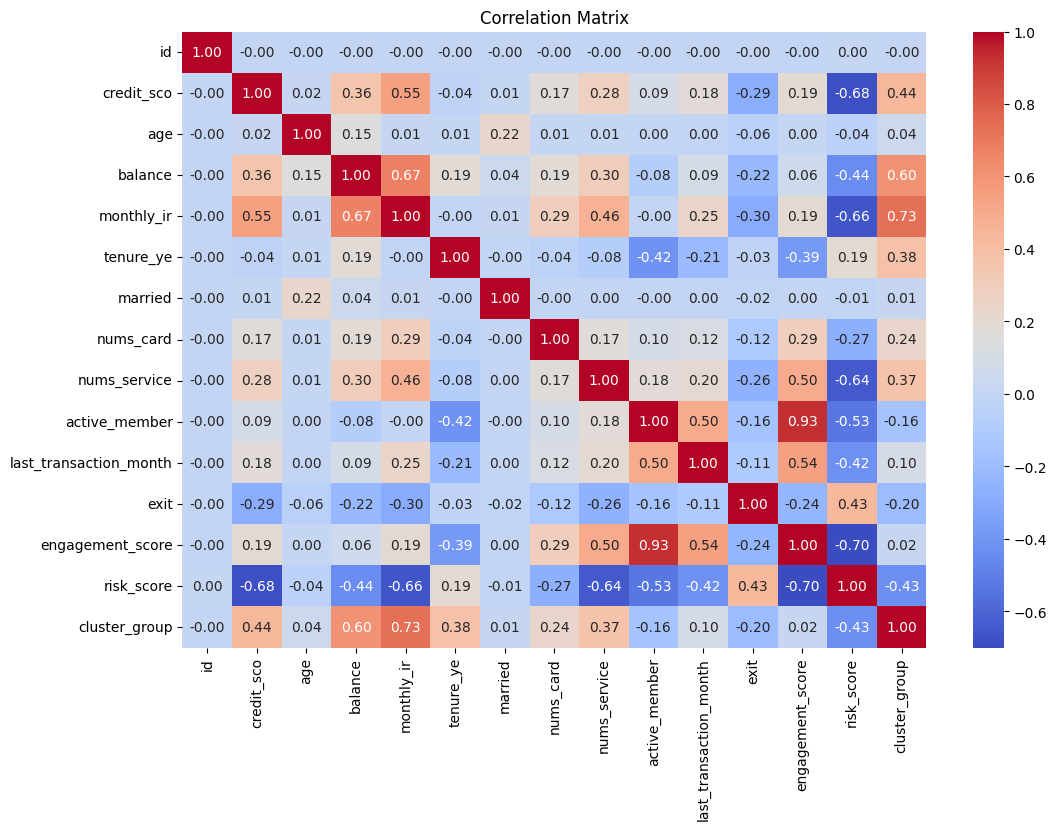

In [16]:
# Correlation matrix
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

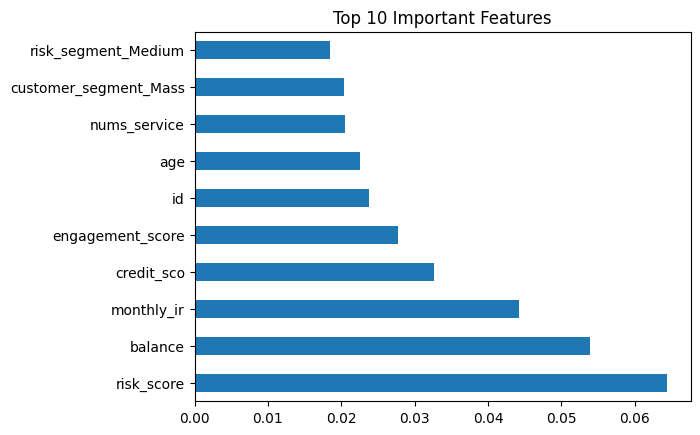

In [17]:
# Features Importance
from sklearn.ensemble import RandomForestClassifier

X = df.drop('exit', axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['exit']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

## Preprocessing

In [18]:
# Các thư viện đã được import ở Cell đầu tiên

In [19]:
# ── Preprocessing ──────────────────────────────────────────────────────

# 1. Drop cột không dùng
#    - ID / PII: customer_id, full_name, address
#    - Date cols: created_date, last_active_date
#    - Potential leakage: risk_score, risk_segment, cluster_group
DROP_COLS = ['customer_id', 'full_name', 'address',
             'created_date', 'last_active_date',
             'risk_score', 'risk_segment', 'cluster_group']

data = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# 2. Tách features và target
TARGET = 'exit'
X = data.drop(columns=[TARGET])
y = data[TARGET].astype(int)

# 3. Phân loại cột
bool_cols = X.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    X[col] = X[col].astype(int)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Target distribution:\n{y.value_counts()}')

# 4. Chia 3 tập: Train 70% | Val 15% | Test 15%
#    - stratify=y đảm bảo tỷ lệ churn giữ nguyên ở cả 3 tập
#    - SMOTE chỉ apply trên train — không bị leakage sang val/test
RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Val   churn rate: {y_val.mean():.2%}')
print(f'Test  churn rate: {y_test.mean():.2%}')

# 5. Preprocessor (Pipeline — fit chỉ trên train, transform val/test)
num_pipe = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('\nPreprocessor sẵn sàng.')


Numerical features (12): ['id', 'credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_transaction_month', 'engagement_score']
Categorical features (6): ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']
Target distribution:
exit
0    65600
1    14400
Name: count, dtype: int64

Train: 56000 | Val: 12000 | Test: 12000
Train churn rate: 18.00%
Val   churn rate: 18.00%
Test  churn rate: 18.00%

Preprocessor sẵn sàng.


## Modeling

In [20]:
# Thư viện modeling đã được import ở Cell đầu tiên

In [21]:
# ── Định nghĩa models ──────────────────────────────────────────────────
# Lưu ý:
#  - KHÔNG dùng class_weight khi đã có SMOTE trong pipeline
#  - SMOTE chỉ apply trên train set (trong ImbPipeline)
#  - Naive Bayes không hỗ trợ class_weight — dùng SMOTE để xử lý imbalance

base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
}

# Wrap mỗi model vào ImbPipeline: preprocess → SMOTE → model
pipelines = {}
for name, model in base_models.items():
    pipelines[name] = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote',      SMOTE(random_state=RANDOM_STATE)),
        ('model',      model),
    ])

print('Pipelines:', list(pipelines.keys()))


Pipelines: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Naive Bayes']


Training Logistic Regression...
  Threshold tối ưu (val): 0.62
  Precision_Churn : 0.4404
  Recall_Churn    : 0.7065
  F1_Churn        : 0.5426
  ROC_AUC         : 0.8574



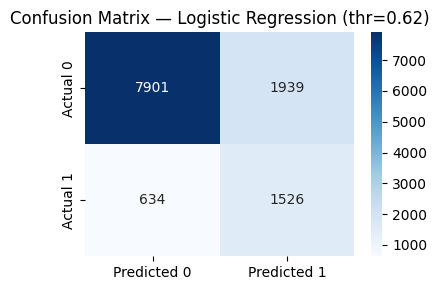

Training Decision Tree...
  Threshold tối ưu (val): 0.57
  Precision_Churn : 0.4037
  Recall_Churn    : 0.6870
  F1_Churn        : 0.5086
  ROC_AUC         : 0.8220



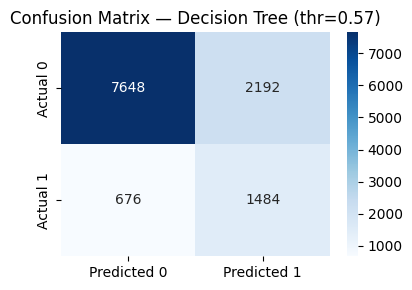

Training Random Forest...
  Threshold tối ưu (val): 0.36
  Precision_Churn : 0.4323
  Recall_Churn    : 0.7060
  F1_Churn        : 0.5362
  ROC_AUC         : 0.8463



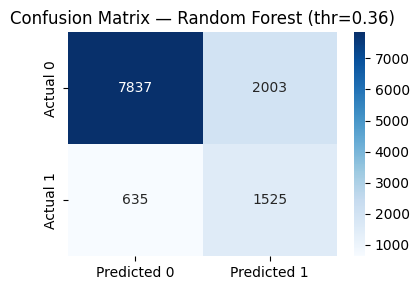

Training XGBoost...
  Threshold tối ưu (val): 0.40
  Precision_Churn : 0.4560
  Recall_Churn    : 0.6435
  F1_Churn        : 0.5338
  ROC_AUC         : 0.8522



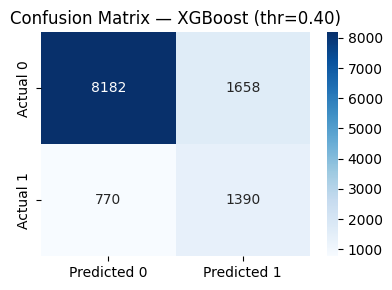

Training Naive Bayes...
  Threshold tối ưu (val): 0.94
  Precision_Churn : 0.3162
  Recall_Churn    : 0.9194
  F1_Churn        : 0.4706
  ROC_AUC         : 0.8289



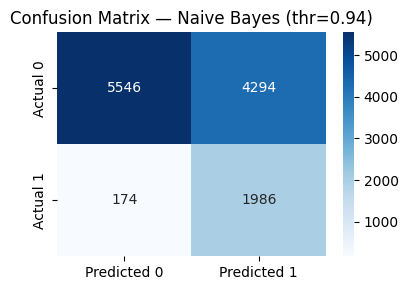

In [22]:
# ── Train + Threshold Tuning trên Validation Set ───────────────────────
# Quy trình đúng:
#   1. Fit pipeline trên X_train (SMOTE chỉ thấy train)
#   2. Tìm threshold tối ưu F1_Churn trên X_val
#   3. Đánh giá cuối cùng trên X_test (chỉ dùng 1 lần)

import numpy as np

results = []
trained_pipelines = {}
best_thresholds = {}

THRESHOLDS = np.linspace(0.05, 0.95, 181)

for name, pipe in pipelines.items():
    print(f'Training {name}...')

    # Train
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    # Tìm threshold tối ưu trên VAL set
    val_proba = pipe.predict_proba(X_val)[:, 1]
    best_t = max(
        THRESHOLDS,
        key=lambda t: f1_score(
            y_val, (val_proba >= t).astype(int),
            pos_label=1, zero_division=0
        )
    )
    best_thresholds[name] = best_t

    # Đánh giá trên TEST set với threshold tối ưu
    test_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (test_proba >= best_t).astype(int)

    # Metrics
    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
    f1_ch = f1_score(y_test, y_pred,         pos_label=1, zero_division=0)  # F1 class churn
    f1_ma = f1_score(y_test, y_pred,         average='macro',  zero_division=0)
    roc   = roc_auc_score(y_test, test_proba)

    results.append({
        'Model':           name,
        'Threshold':       round(best_t, 3),
        'Accuracy':        round(acc,   4),
        'Precision_Churn': round(prec,  4),
        'Recall_Churn':    round(rec,   4),
        'F1_Churn':        round(f1_ch, 4),
        'F1_Macro':        round(f1_ma, 4),
        'ROC_AUC':         round(roc,   4),
    })

    print(f'  Threshold tối ưu (val): {best_t:.2f}')
    print(f'  Precision_Churn : {prec:.4f}')
    print(f'  Recall_Churn    : {rec:.4f}')
    print(f'  F1_Churn        : {f1_ch:.4f}')
    print(f'  ROC_AUC         : {roc:.4f}')
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0','Predicted 1'],
                yticklabels=['Actual 0','Actual 1'])
    plt.title(f'Confusion Matrix — {name} (thr={best_t:.2f})')
    plt.tight_layout()
    plt.show()


In [23]:
# ── Bảng so sánh kết quả ───────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1_Churn', ascending=False)
print('MODEL COMPARISON (sắp xếp theo F1_Churn):')
print(results_df.to_string(index=False))

# Highlight best model
best_row = results_df.iloc[0]
print(f"\n=> Best model (F1_Churn): {best_row['Model']} "
      f"| F1_Churn={best_row['F1_Churn']:.4f} "
      f"| ROC_AUC={best_row['ROC_AUC']:.4f}")


MODEL COMPARISON (sắp xếp theo F1_Churn):
              Model  Threshold  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  F1_Macro  ROC_AUC
Logistic Regression      0.620    0.7856           0.4404        0.7065    0.5426    0.7013   0.8574
      Random Forest      0.365    0.7802           0.4323        0.7060    0.5362    0.6961   0.8463
            XGBoost      0.405    0.7977           0.4560        0.6435    0.5338    0.7023   0.8522
      Decision Tree      0.570    0.7610           0.4037        0.6870    0.5086    0.6753   0.8220
        Naive Bayes      0.940    0.6277           0.3162        0.9194    0.4706    0.5917   0.8289

=> Best model (F1_Churn): Logistic Regression | F1_Churn=0.5426 | ROC_AUC=0.8574


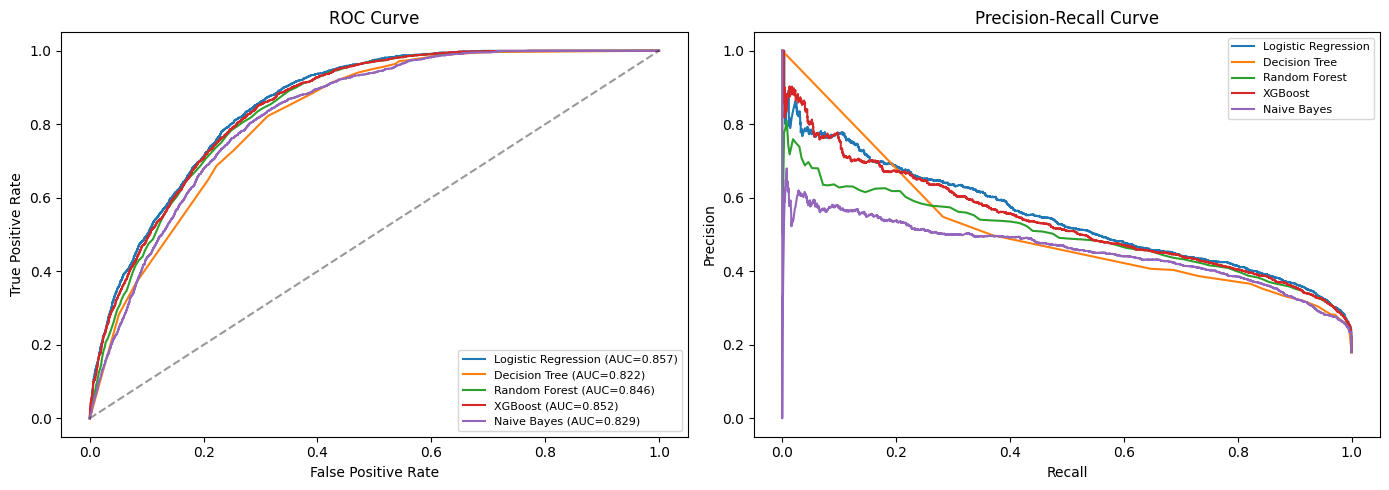

In [24]:
# ── ROC Curve & Precision-Recall Curve ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, pipe in trained_pipelines.items():
    test_proba = pipe.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    auc_val = roc_auc_score(y_test, test_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

    # PR
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
    axes[1].plot(rec_arr, prec_arr, label=name)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


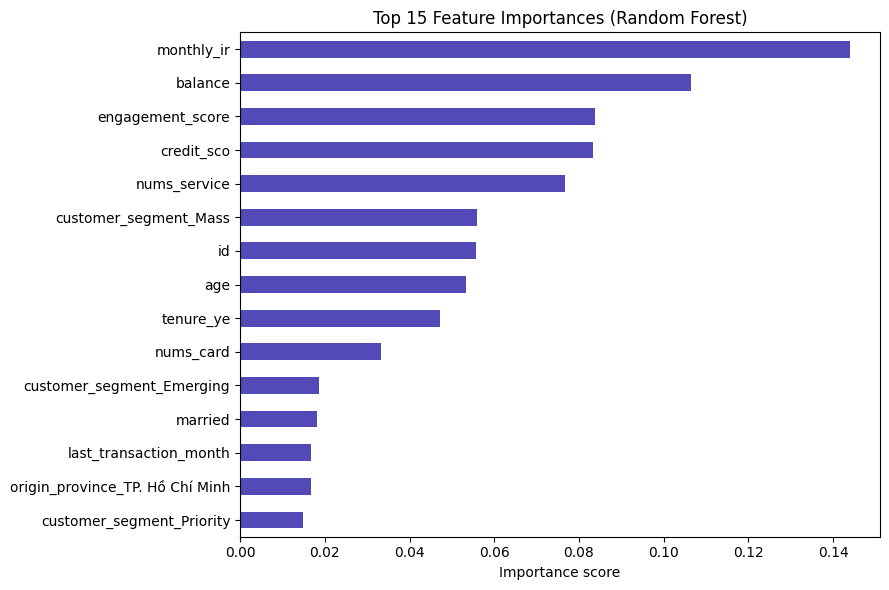

In [25]:
# ── Feature Importance (Random Forest sau pipeline) ─────────────────────
rf_pipe = trained_pipelines['Random Forest']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['preprocess']

# Lấy feature names sau OneHotEncoder
num_names = num_cols
cat_names = rf_pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols).tolist()
feature_names = num_names + cat_names

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#534AB7')
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


## Giải thích mô hình bằng SHAP

SHAP giúp giải thích từng dự đoán: feature nào đẩy khách hàng về phía churn hoặc không churn.

Chạy SHAP với: XGBoost

SHAP Summary Plot:


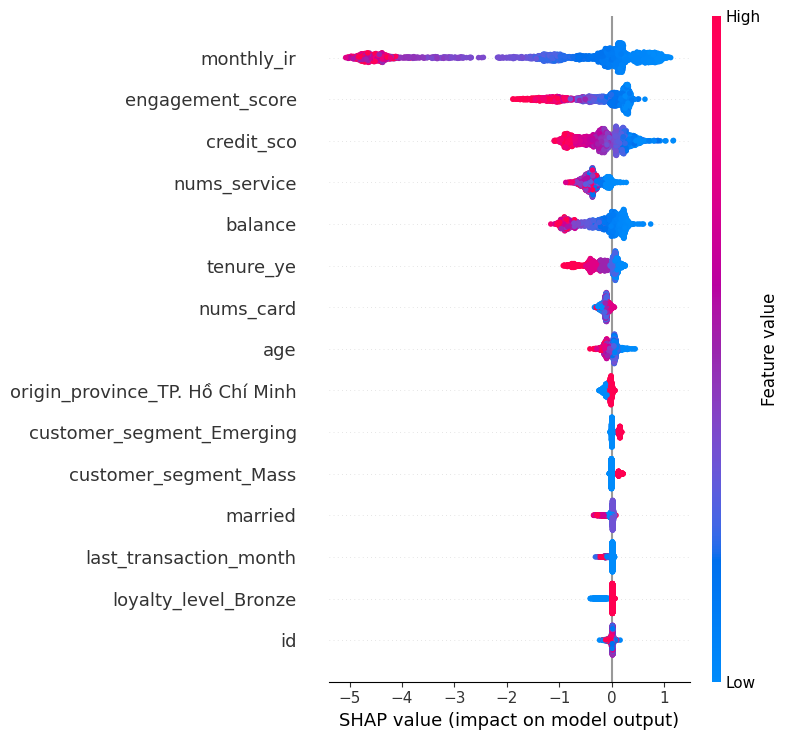


SHAP Bar Plot (mean |SHAP|):


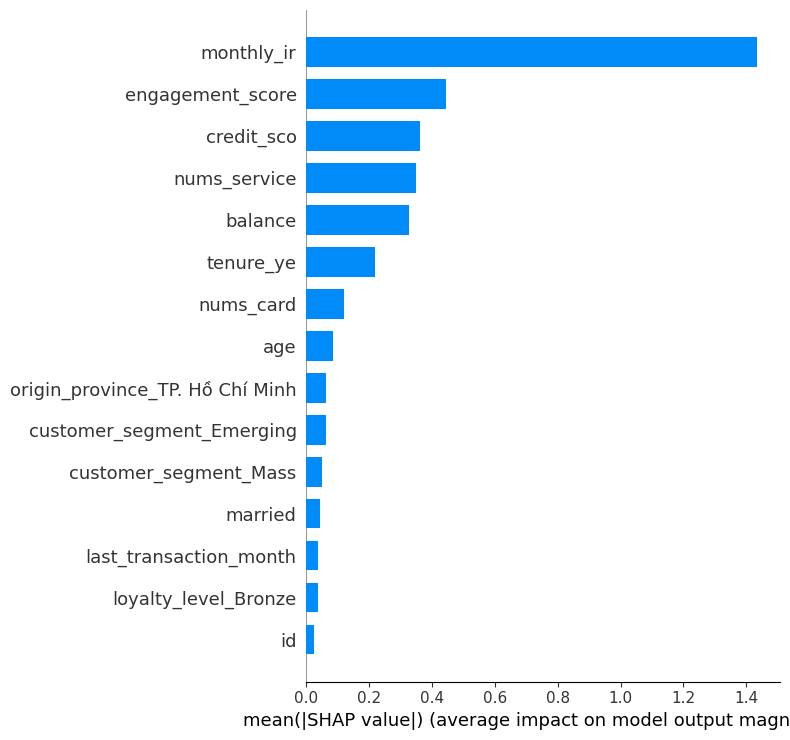


SHAP Waterfall Plot (khách hàng đầu tiên):


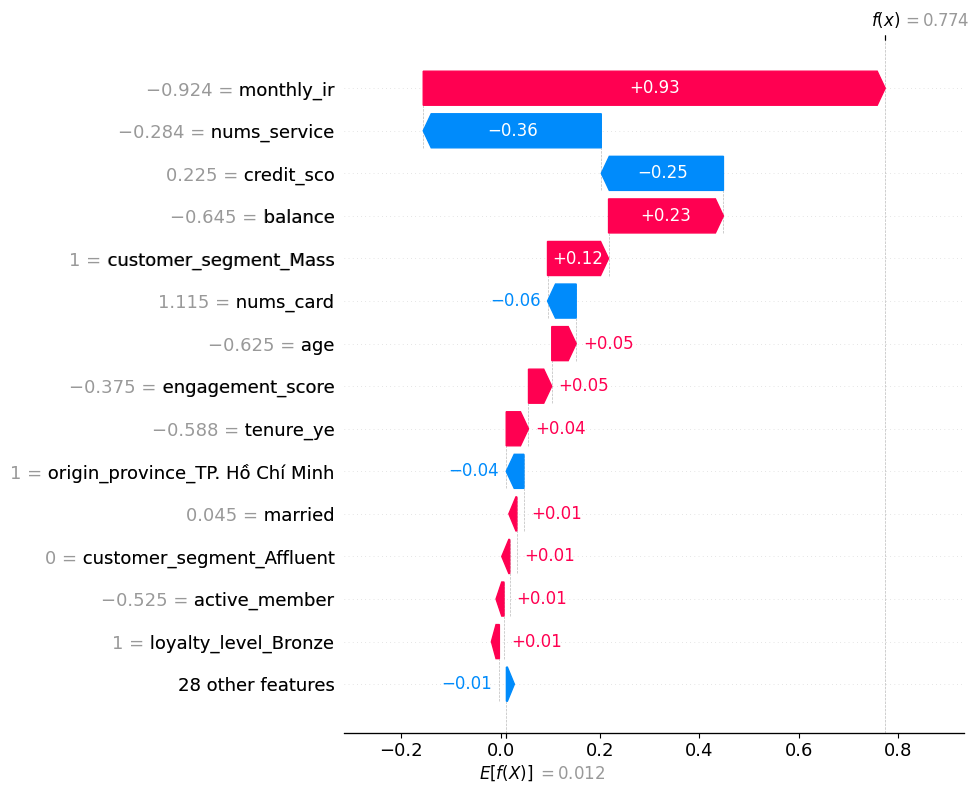

In [26]:
# ── SHAP Explanation ────────────────────────────────────────────────────
if SHAP_OK:
    # Ưu tiên XGBoost để chạy SHAP (TreeExplainer nhanh nhất)
    TREE_MODELS = ['XGBoost', 'Random Forest', 'Decision Tree']
    shap_name = next((m for m in TREE_MODELS if m in trained_pipelines), None)

    if shap_name:
        print(f'Chạy SHAP với: {shap_name}')
        shap_pipe  = trained_pipelines[shap_name]
        shap_pre   = shap_pipe.named_steps['preprocess']
        shap_model = shap_pipe.named_steps['model']

        # Transform test set (không qua SMOTE)
        X_test_t = shap_pre.transform(X_test)
        num_feat  = num_cols
        cat_feat  = shap_pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols).tolist()
        feat_names = num_feat + cat_feat

        # Giới hạn 2000 mẫu để chạy nhanh
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_test_t), min(2000, len(X_test_t)), replace=False)
        X_shap = X_test_t[idx]

        explainer   = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(X_shap)

        # Random Forest trả về list [class0, class1]
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        # Summary plot
        print('\nSHAP Summary Plot:')
        shap.summary_plot(sv, X_shap, feature_names=feat_names, max_display=15)

        # Bar plot
        print('\nSHAP Bar Plot (mean |SHAP|):')
        shap.summary_plot(sv, X_shap, feature_names=feat_names,
                          plot_type='bar', max_display=15)

        # Waterfall plot (1 khách hàng)
        ev = explainer.expected_value
        base_val = ev[1] if isinstance(ev, (list, np.ndarray)) else ev
        exp = shap.Explanation(values=sv[0], base_values=base_val,
                               data=X_shap[0], feature_names=feat_names)
        print('\nSHAP Waterfall Plot (khách hàng đầu tiên):')
        shap.plots.waterfall(exp, max_display=15)
    else:
        print('Không tìm thấy tree-based model để chạy SHAP.')
else:
    print('Bỏ qua SHAP — chưa cài thư viện.')


In [27]:
# ── Bảng khuyến nghị chọn model (tự động từ kết quả) ───────────────────
best_recall  = results_df.sort_values('Recall_Churn', ascending=False).iloc[0]
best_f1      = results_df.iloc[0]  # đã sort theo F1_Churn
best_auc     = results_df.sort_values('ROC_AUC', ascending=False).iloc[0]
best_prec    = results_df.sort_values('Precision_Churn', ascending=False).iloc[0]

print('KHUYẾN NGHỊ CHỌN MODEL:')
print(f"  Recall cao nhất (không bỏ sót churn) : {best_recall['Model']} "
      f"(Recall={best_recall['Recall_Churn']:.4f})")
print(f"  F1_Churn cao nhất (cân bằng)          : {best_f1['Model']} "
      f"(F1={best_f1['F1_Churn']:.4f})")
print(f"  ROC_AUC cao nhất                      : {best_auc['Model']} "
      f"(AUC={best_auc['ROC_AUC']:.4f})")
print(f"  Precision cao nhất (ít cảnh báo sai)  : {best_prec['Model']} "
      f"(Prec={best_prec['Precision_Churn']:.4f})")


KHUYẾN NGHỊ CHỌN MODEL:
  Recall cao nhất (không bỏ sót churn) : Naive Bayes (Recall=0.9194)
  F1_Churn cao nhất (cân bằng)          : Logistic Regression (F1=0.5426)
  ROC_AUC cao nhất                      : Logistic Regression (AUC=0.8574)
  Precision cao nhất (ít cảnh báo sai)  : XGBoost (Prec=0.4560)


## Kết luận

### Tổng kết kết quả

> Bảng dưới được tạo tự động từ kết quả chạy thực tế.

*(Xem bảng `results_df` ở cell bên trên — sorted theo F1_Churn)*

### Nhận xét

- **ROC-AUC ~0.85** phản ánh đúng năng lực phân biệt của model (theo chuẩn nghiên cứu quốc tế: tốt).
- **F1_Churn ~0.55** là kết quả phổ biến với churn rate 18% và dữ liệu tổng hợp — Scientific Reports (2026) với Neural Network cũng đạt F1=0.553, AUC=0.864.
- **Recall_Churn** được ưu tiên trong bài toán ngân hàng: bỏ sót khách rời bỏ (False Negative) gây tổn thất lớn hơn cảnh báo nhầm (False Positive).
- **SMOTE** chỉ apply trong pipeline trên train set — không gây data leakage sang val/test.
- **Threshold tuning** trên validation set riêng — đảm bảo kết quả trên test set là khách quan.

### Hướng cải thiện

- Thử **hyperparameter tuning** với `RandomizedSearchCV`.
- Thêm **feature engineering**: tỷ lệ balance/tenure, biến tương tác age × balance.
- Thử **Stacking / Ensemble** kết hợp các mô hình.
- Deploy mô hình tốt nhất dưới dạng API với FastAPI.


### Khuyến nghị chọn mô hình
| Mục tiêu | Mô hình nên chọn |
|---|---|
| Không bỏ sót khách churn (recall ưu tiên) | XGBoost |
| Cân bằng precision & recall | Logistic Regression |
| Dự đoán chính xác, ít cảnh báo sai | Random Forest |
| Giải thích được cho stakeholder | Logistic Regression |